In [2]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler
from scipy.stats import entropy


from sklearn.calibration import calibration_curve

# Loading Data

In [3]:
df = pd.read_pickle("data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

In [4]:
X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)

X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)

In [5]:
df_train.head(3)

,id,industry,business_description_embedding
31138,34170,Financial Services,"[0.019633012,0.009427597,0.006240986,0.0177257..."
15120,16504,Technology Hardware & Equipment,"[0.026561439,-0.049749356,-0.006847293,-0.0088..."
23693,25893,Consumer Durables & Apparel,"[0.0115894,-0.035240766,-0.029952582,0.0226988..."


# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

In [6]:
# Fit the label encoder to the classes (industry names)
le = LabelEncoder()
le.fit(df_train["industry"])
df_train["industry_encoded"] = le.transform(df_train["industry"])


In [7]:
le.classes_

array(['Automobiles & Components', 'Banks', 'Capital Goods',
       'Commercial & Professional Services',
       'Consumer Discretionary Distribution & Retail',
       'Consumer Durables & Apparel', 'Consumer Services',
       'Consumer Staples Distribution & Retail', 'Energy',
       'Equity Real Estate Investment Trusts (REITs)',
       'Financial Services', 'Food, Beverage & Tobacco',
       'Health Care Equipment & Services',
       'Household & Personal Products', 'Insurance', 'Materials',
       'Media & Entertainment',
       'Pharmaceuticals, Biotechnology & Life Sciences',
       'Real Estate Management & Development',
       'Semiconductors & Semiconductor Equipment', 'Software & Services',
       'Technology Hardware & Equipment', 'Telecommunication Services',
       'Transportation', 'Utilities'], dtype=object)

In [8]:
for industry, number in zip(le.classes_, range(len(le.classes_))):
    print(f"{industry} -> {number}")

Automobiles & Components -> 0
Banks -> 1
Capital Goods -> 2
Commercial & Professional Services -> 3
Consumer Discretionary Distribution & Retail -> 4
Consumer Durables & Apparel -> 5
Consumer Services -> 6
Consumer Staples Distribution & Retail -> 7
Energy -> 8
Equity Real Estate Investment Trusts (REITs) -> 9
Financial Services -> 10
Food, Beverage & Tobacco -> 11
Health Care Equipment & Services -> 12
Household & Personal Products -> 13
Insurance -> 14
Materials -> 15
Media & Entertainment -> 16
Pharmaceuticals, Biotechnology & Life Sciences -> 17
Real Estate Management & Development -> 18
Semiconductors & Semiconductor Equipment -> 19
Software & Services -> 20
Technology Hardware & Equipment -> 21
Telecommunication Services -> 22
Transportation -> 23
Utilities -> 24


In [9]:
le = LabelEncoder()
le.fit(df_val["industry"])
df_val["industry_encoded"] = le.transform(df_val["industry"])

In [10]:
le.classes_

array(['Automobiles & Components', 'Banks', 'Capital Goods',
       'Commercial & Professional Services',
       'Consumer Discretionary Distribution & Retail',
       'Consumer Durables & Apparel', 'Consumer Services',
       'Consumer Staples Distribution & Retail', 'Energy',
       'Equity Real Estate Investment Trusts (REITs)',
       'Financial Services', 'Food, Beverage & Tobacco',
       'Health Care Equipment & Services',
       'Household & Personal Products', 'Insurance', 'Materials',
       'Media & Entertainment',
       'Pharmaceuticals, Biotechnology & Life Sciences',
       'Real Estate Management & Development',
       'Semiconductors & Semiconductor Equipment', 'Software & Services',
       'Technology Hardware & Equipment', 'Telecommunication Services',
       'Transportation', 'Utilities'], dtype=object)

In [11]:
for industry, number in zip(le.classes_, range(len(le.classes_))):
    print(f"{industry} -> {number}")

Automobiles & Components -> 0
Banks -> 1
Capital Goods -> 2
Commercial & Professional Services -> 3
Consumer Discretionary Distribution & Retail -> 4
Consumer Durables & Apparel -> 5
Consumer Services -> 6
Consumer Staples Distribution & Retail -> 7
Energy -> 8
Equity Real Estate Investment Trusts (REITs) -> 9
Financial Services -> 10
Food, Beverage & Tobacco -> 11
Health Care Equipment & Services -> 12
Household & Personal Products -> 13
Insurance -> 14
Materials -> 15
Media & Entertainment -> 16
Pharmaceuticals, Biotechnology & Life Sciences -> 17
Real Estate Management & Development -> 18
Semiconductors & Semiconductor Equipment -> 19
Software & Services -> 20
Technology Hardware & Equipment -> 21
Telecommunication Services -> 22
Transportation -> 23
Utilities -> 24


In [12]:
y_train = df_train["industry_encoded"]
y_val =  df_val["industry_encoded"]

In [13]:
# Returns "True" if both arrays have the same labels.
np.array_equal(np.unique(y_train), np.unique(y_val))

True

All industries are encoded now. Both (train- and validation set) contain the same industries. The following table depicts the allocation of each code to the corresponding industry.

| Code | Industry                                     | Code | Industry                                       |
|------|----------------------------------------------|------|------------------------------------------------|
| 0    | Automobiles & Components                     | 13   | Household & Personal Products                  |
| 1    | Banks                                        | 14   | Insurance                                      |
| 2    | Capital Goods                                | 15   | Materials                                      |
| 3    | Commercial & Professional Services           | 16   | Media & Entertainment                          |
| 4    | Consumer Discretionary Distribution & Retail | 17   | Pharmaceuticals, Biotechnology & Life Sciences |
| 5    | Consumer Durables & Apparel                  | 18   | Real Estate Management & Development           |
| 6    | Consumer Services                            | 19   | Semiconductors & Semiconductor Equipment       |
| 7    | Consumer Staples Distribution & Retail       | 20   | Software & Services                            |
| 8    | Energy                                       | 21   | Technology Hardware & Equipment                |
| 9    | Equity Real Estate Investment Trusts (REITs) | 22   | Telecommunication Services                     |
| 10   | Financial Services                           | 23   | Transportation                                 |
| 11   | Food, Beverage & Tobacco                     | 24   | Utilities                                      |
| 12   | Health Care Equipment & Services             |      |                                                |


# Visualize the data

### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

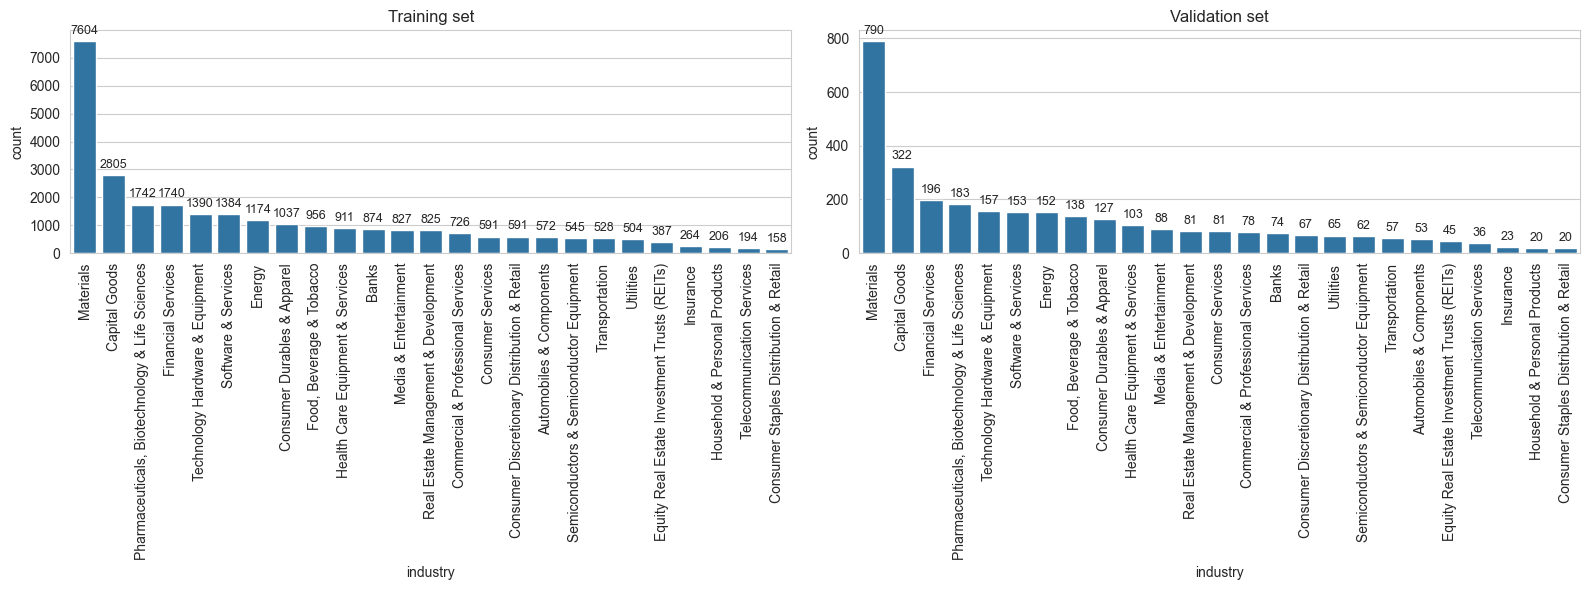

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, df, title in zip(axes, [df_train, df_val], ["Training set", "Validation set"]):
    sns.countplot(
        data=df,
        x="industry",
        order=df["industry"].value_counts().index,
        ax=ax
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90)
    ax.bar_label(ax.containers[0], fontsize=9, padding=3)

plt.tight_layout()
plt.show()

The industry _Materials_ is overrepresented towards all other industries. Due to this issue, a classification model will recognise companies of the label _Materials_ better than others. Nevertheless, the distribution is more or less the same for both train and val datasets.

### PCA - Dimensionality reduction and visualization

In [15]:
# Performa a PCA and plot the projected data. Color the scatter plot based on the classes
# Analyse what you see
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

In [16]:
pca_df = pd.DataFrame({
    "PC1": X_train_pca[:, 0],
    "PC2": X_train_pca[:, 1],
    "industry_encoded": df_train["industry_encoded"],
    "industry": le.inverse_transform(df_train["industry_encoded"])
})

fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="industry",
    title="PCA of Training Data",
    color_discrete_sequence=px.colors.qualitative.Alphabet,
    hover_data=["industry"]
)

fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.update_layout(
    width=800,
    height=600,
    legend_title_text="Industry Label"
)

fig.show()

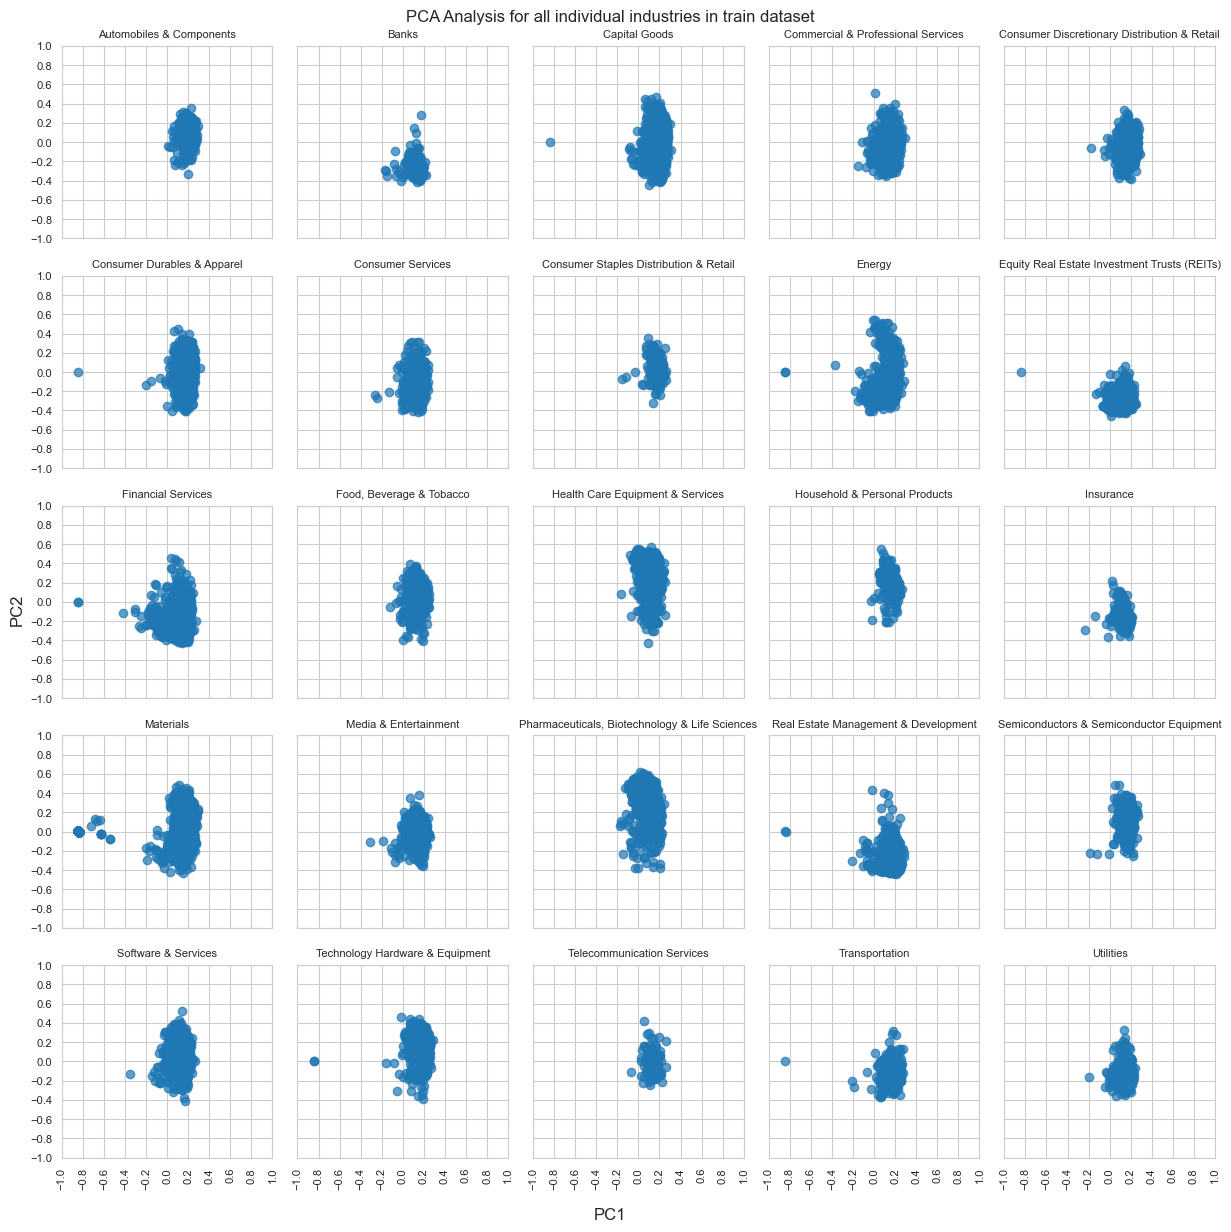

In [17]:
num_classes = len(le.classes_)  # 25

# Grid for subplots (5x5)
n_cols = 5
n_rows = int(np.ceil(num_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.5, n_rows*2.5), sharex=True, sharey=True)

axes = axes.flatten()  # Flatten in order to iterate more efficiently

for i, industry_label in enumerate(le.classes_):
    ax = axes[i]
    # All points of this industry
    idx = df_train["industry"] == industry_label
    ax.scatter(X_train_pca[idx, 0], X_train_pca[idx, 1], alpha=0.7)
    ax.set_title(industry_label, fontsize=8)
    ax.tick_params(axis='x', labelsize=8, rotation=90)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_yticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_xticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

fig.supxlabel("PC1", fontsize=12)
fig.supylabel("PC2", fontsize=12)
fig.suptitle("PCA Analysis for all individual industries in train dataset")
plt.tight_layout()
plt.show()


The above scatterplot depicts PC1 and PC2 for each individual industry. It can be seen that all industries show clear clusters, which means that the embeddings of companies of the same industry contain similar semantic information. Nevertheless, the following industries contain _"outliers"_ based on the 2 principal components:

- Capital Goods
- Consumer Durables & Apparel
- Energy
- Equity Real Estate Investment Trusts (REITs)
- Financial Services
- Real Estate Management & Development
- Technology Hardware & Equipment
- Transportation
- (Materials shows 2 clusters)

These _"outliers"_ may be there because the embeddings of these datapoints contain special wording or information. But, because the embeddings are of 768 dimensions and the PCA shows only 2 components of them, this is not a definitive criteria to remove these points from the data set.

# Fitting and comparing Classifier Models

## Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors:
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots!

## Logistic Regression

In [18]:
# Logistic Regression Classification
clf = LogisticRegression(random_state=42).fit(X_train, y_train)
y_pred = clf.predict(X_val)

In [19]:
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"F1 Score (weighted): {f1_score(y_val, y_pred, average="weighted"):.4f}")

Accuracy: 0.7720
F1 Score (weighted): 0.7663


The formula for the accuracy is the following:

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mtext mathvariant="monospace">accuracy</mtext>
  <mo stretchy="false">(</mo>
  <mi>y</mi>
  <mo>,</mo>
  <mrow data-mjx-texclass="ORD">
    <mover>
      <mi>y</mi>
      <mo stretchy="false">^</mo>
    </mover>
  </mrow>
  <mo stretchy="false">)</mo>
  <mo>=</mo>
  <mfrac>
    <mn>1</mn>
    <msub>
      <mi>n</mi>
      <mtext>samples</mtext>
    </msub>
  </mfrac>
  <munderover>
    <mo data-mjx-texclass="OP">&#x2211;</mo>
    <mrow data-mjx-texclass="ORD">
      <mi>i</mi>
      <mo>=</mo>
      <mn>0</mn>
    </mrow>
    <mrow data-mjx-texclass="ORD">
      <msub>
        <mi>n</mi>
        <mtext>samples</mtext>
      </msub>
      <mo>&#x2212;</mo>
      <mn>1</mn>
    </mrow>
  </munderover>
  <mn>1</mn>
  <mo stretchy="false">(</mo>
  <msub>
    <mrow data-mjx-texclass="ORD">
      <mover>
        <mi>y</mi>
        <mo stretchy="false">^</mo>
      </mover>
    </mrow>
    <mi>i</mi>
  </msub>
  <mo>=</mo>
  <msub>
    <mi>y</mi>
    <mi>i</mi>
  </msub>
  <mo stretchy="false">)</mo>
</math>

The accuracy takes the true value and predicted value as inputs. All truly predicted values are being summed up and divided by the number of samples. The result is a decimal value between 0 and 1, where 1 is the best result possible. The result can be seen as a percentage of correctly predicted samples to the total number of samples.

The formula for the F1 score is the following:

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mtext>F1</mtext>
  <mo>=</mo>
  <mfrac>
    <mrow>
      <mn>2</mn>
      <mo>&#x2217;</mo>
      <mtext>TP</mtext>
    </mrow>
    <mrow>
      <mn>2</mn>
      <mo>&#x2217;</mo>
      <mtext>TP</mtext>
      <mo>+</mo>
      <mtext>FP</mtext>
      <mo>+</mo>
      <mtext>FN</mtext>
    </mrow>
  </mfrac>
</math>

The F1 score divides the true positives by the sum of the true positives, false positives and false negatives and multiplies the division by 2. This formula raises a decimal value between 0 and 1, where again 1 is the best possible value. In our specific case (multiclass), we want an overall F1 score, not one for all classes. Therefore, we weight all the 25 different F1 scores by the number of true instances per class.

Although the model hyperparameters have not been optimized, the model performs not too bad with a weighted F1 Score of 0.77. Note that the model used l2 regularization per default.

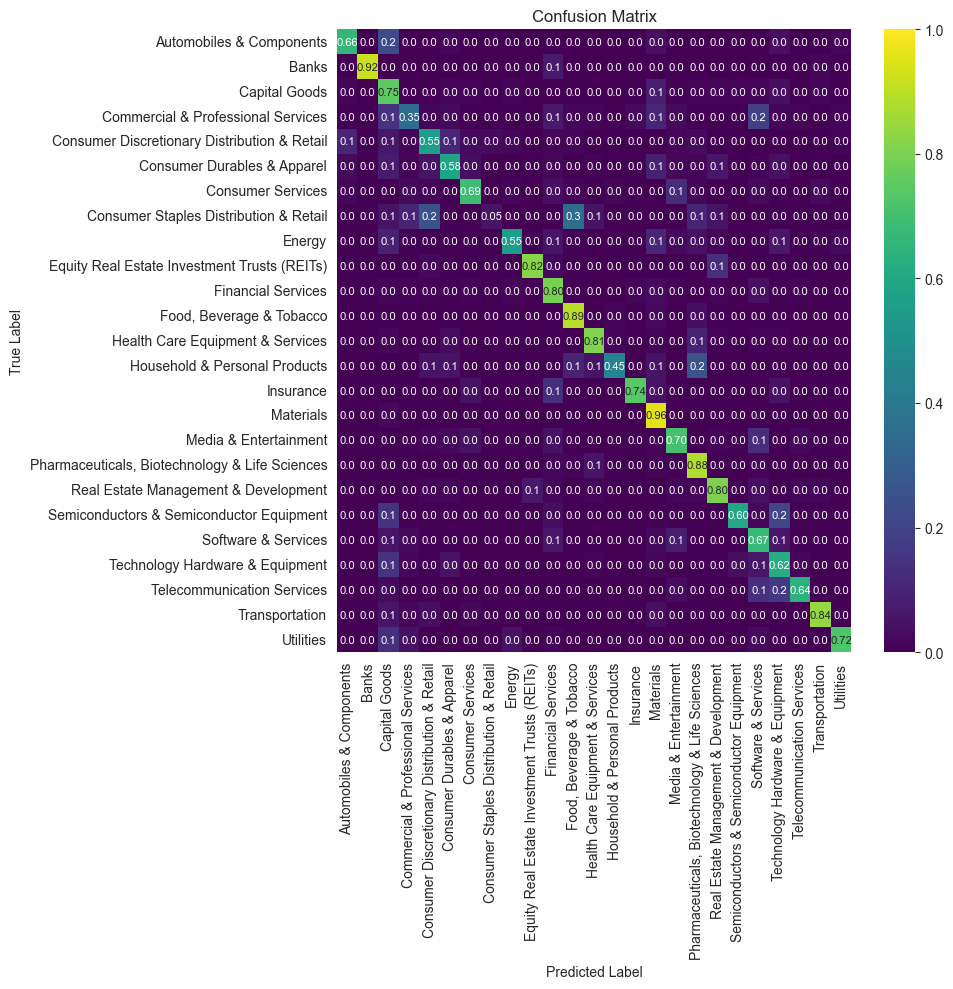

In [20]:
cm = confusion_matrix(y_val, y_pred, normalize="true")

# Annot-Array (only values on the diagonal will be .2f)
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i == j:
            annot[i, j] = f"{cm[i, j]:.2f}"  # diagonal: 2 decimals
        else:
            annot[i, j] = f"{cm[i, j]:.1f}"  # rest: 1 decimal

plt.figure(figsize=(10, 10))
sns.heatmap(cm,
            annot=annot,                     # ->annot array
            cmap="viridis",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            vmin=0, vmax=1,
            fmt="",
            annot_kws={"fontsize": 8}
            )

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The above heatmap shows the true label on the y-axis and the predicted label on the x-axis for each industry. The diagonal is clearly visible, which means that most of the industries were classified correctly. The only industry that could not be classified correctly is _Consumer Staples Distribution & Retail_, where only 5% of the samples were correctly classified. This can be explained by the very small number of occurrence in both training (158) and validation (20) sets. It seems that the model cannot learn enough to predict the class in the right way. In general, the model predicts industries with many datapoints better than industries with less datapoints.

## kNN Classifier

In [21]:
neigh = KNeighborsClassifier(n_neighbors=15, weights="distance", p=1, metric="euclidean")
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_val)
neigh.fit(X_train, y_train)

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\leoni\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\leoni\Documents\UZH\1. Semester\Foundations of Data Science\Practical_1\FDS25-T043\venv\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "C:\Users\leoni\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\leoni\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\leoni\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap

,n_neighbors,15
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [22]:
y_pred_knn = neigh.predict(X_val)

In [23]:
print(f"Accuracy: {accuracy_score(y_val, y_pred_knn):.4f}")
print(f"F1 Score (weighted): {f1_score(y_val, y_pred_knn, average="weighted"):.4f}")

Accuracy: 0.7755
F1 Score (weighted): 0.7698


The KNN classifier performed similarly good as the logistic regression.

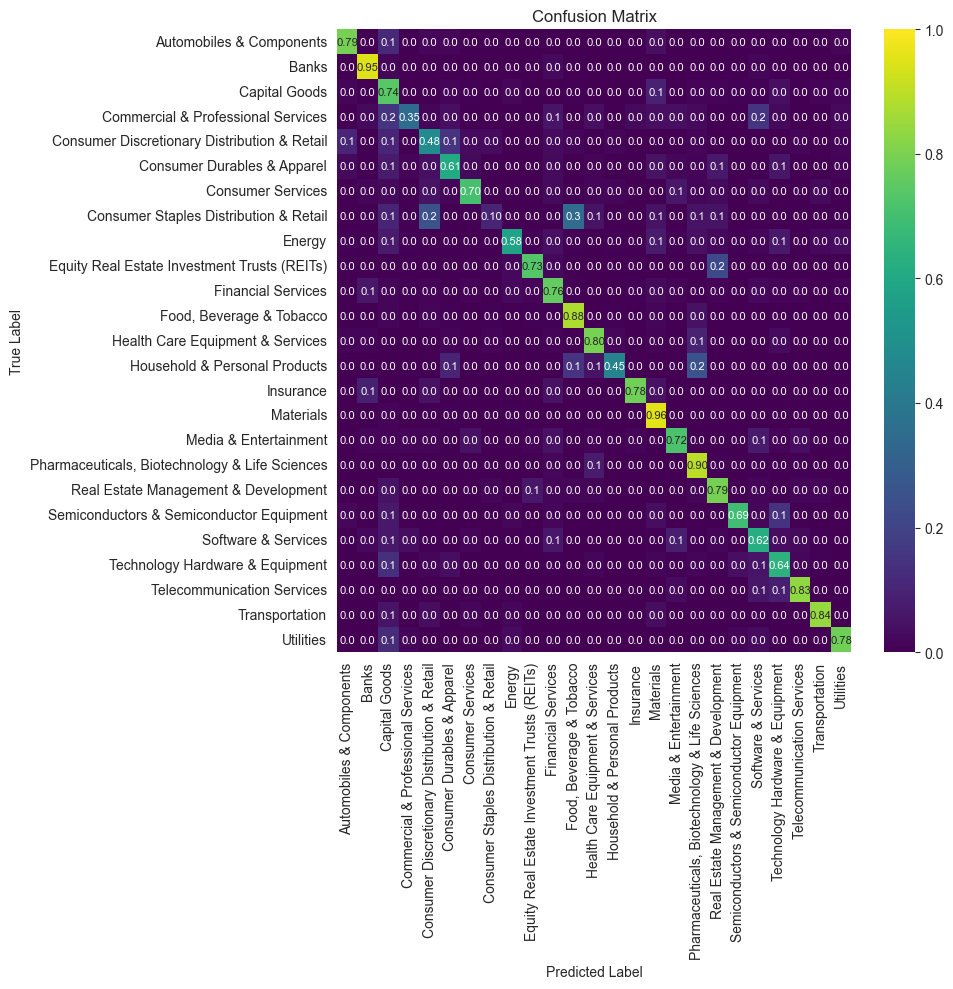

In [24]:
cm = confusion_matrix(y_val, y_pred_knn, normalize="true")

# Annot-Array (only values on the diagonal will be .2f)
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i == j:
            annot[i, j] = f"{cm[i, j]:.2f}"  # diagonal: 2 decimals
        else:
            annot[i, j] = f"{cm[i, j]:.1f}"  # rest: 1 decimal

plt.figure(figsize=(10, 10))
sns.heatmap(cm,
            annot=annot,
            cmap="viridis",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            vmin=0, vmax=1,
            fmt="",
            annot_kws={"fontsize": 8}
            )

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The above heatmap shows the same information as before, but for the KNN classifier. The same observations can be done here: The diagonal is clearly visible and industries with a larger amount of datasamples can be better classified than the ones with a smaller amount of samples.

## Conclusion

Both models, Logistic Regression and kNN, achieved comparable performance with weighted F1 scores around 0.77, indicating a reasonable ability to classify industries based on their business description embeddings. The confusion matrices show that classes with more training samples are predicted more accurately, while underrepresented industries, such as Consumer Staples Distribution & Retail, are harder to classify. Overall, the embeddings contain meaningful signal for industry classification, but class imbalance and overlapping class semantics limit model performance.

# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of a industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- The designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

In [82]:
def confidence_weighted_f1(y_true, y_pred, confidence):
    weighted_tp = np.sum(confidence * (y_pred == 1) * (y_true == 1))
    weighted_fp = np.sum(confidence * (y_pred == 1) * (y_true == 0))
    weighted_fn = np.sum(confidence * (y_pred == 0) * (y_true == 1))
    precision = weighted_tp / (weighted_tp + weighted_fp) if (weighted_tp + weighted_fp) > 0 else 0
    recall = weighted_tp / (weighted_tp + weighted_fn) if (weighted_tp + weighted_fn) > 0 else 0
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

def multiclass_confidence_weighted_f1(y_true, y_pred, y_proba, average='macro'):
    classes = np.unique(y_true)
    f1_scores = []
    supports = []

    for cls in classes:
        y_true_bin = (y_true == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)
        # Ensure y_proba has shape (n_samples, n_classes)
        if y_proba.ndim == 1:
            y_proba = y_proba.reshape(-1, 1)
        if y_proba.shape[1] <= cls:
            # Add dummy column if some class missing
            y_proba = np.hstack([y_proba, np.zeros((y_proba.shape[0], cls - y_proba.shape[1] + 1))])
        conf = np.where(y_pred == cls, np.max(y_proba, axis=1), 0)
        f1_c = confidence_weighted_f1(y_true_bin, y_pred_bin, conf)
        f1_scores.append(f1_c)
        supports.append(np.sum(y_true == cls))

    f1_scores = np.nan_to_num(f1_scores)
    supports = np.array(supports)

    if average == 'macro':
        return np.mean(f1_scores)
    elif average == 'weighted':
        return np.sum(f1_scores * supports) / np.sum(supports)
    else:
        raise ValueError("average must be 'macro' or 'weighted'")

In [83]:
# ----------------------------
# Load data
# ----------------------------
text_embeddings = pd.read_pickle("data/df_train.pkl")
fin_data = pd.read_pickle("data/df_financials_train.pkl")

# Label encode target
le = LabelEncoder()
text_embeddings['industry'] = le.fit_transform(text_embeddings['industry'])

# Merge datasets
df = pd.merge(text_embeddings, fin_data, on='id', how='left')

# Financial columns
financial_numeric_cols = ['net_profit_margin', 'asset_turnover']
financial_cat_cols = ['country_code']

# Clean numeric financials
for col in financial_numeric_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    df[col] = np.log1p(df[col].clip(lower=0))

# Add interactions
df['netprofit_asset'] = df['net_profit_margin'] * df['asset_turnover']
df['netprofit_over_asset'] = df['net_profit_margin'] / (df['asset_turnover'] + 1e-6)
financial_numeric_cols += ['netprofit_asset', 'netprofit_over_asset']

# ----------------------------
# Train / Test split
# ----------------------------
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df['industry'], random_state=42)
y_test = df_test['industry'].values

# ----------------------------
# Expand embeddings
# ----------------------------
def expand_embeddings(series):
    return np.vstack(series.apply(lambda x: np.array(list(map(float, ast.literal_eval(x))))))

emb_train = expand_embeddings(df_train['business_description_embedding'])
emb_test = expand_embeddings(df_test['business_description_embedding'])

# PCA
pca = PCA(n_components=75, random_state=42)
emb_train_pca = pca.fit_transform(emb_train)
emb_test_pca = pca.transform(emb_test)

# ----------------------------
# Oversample training set (financial branch)
# ----------------------------
ros = RandomOverSampler(random_state=42)

# Financial preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])
fin_preproc = ColumnTransformer([
    ('num', numeric_transformer, financial_numeric_cols),
    ('cat', categorical_transformer, financial_cat_cols)
])

X_train_fin = fin_preproc.fit_transform(df_train[financial_numeric_cols + financial_cat_cols])
X_test_fin = fin_preproc.transform(df_test[financial_numeric_cols + financial_cat_cols])
X_train_fin_res, y_train_fin_res = ros.fit_resample(X_train_fin, df_train['industry'].values)

# ----------------------------
# Text model: KNN + calibrated probabilities
# ----------------------------
knn = KNeighborsClassifier(n_neighbors=10, weights='distance', n_jobs=-1)
knn_cal = CalibratedClassifierCV(knn, method='sigmoid', cv=3, n_jobs=-1)
knn_cal.fit(emb_train_pca, df_train['industry'].values)
y_proba_text = knn_cal.predict_proba(emb_test_pca)
y_pred_text = np.argmax(y_proba_text, axis=1)

# ----------------------------
# Financial model: HGB + calibrated probabilities
# ----------------------------
hgb = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.05, class_weight='balanced', random_state=42)
hgb_cal = CalibratedClassifierCV(hgb, method='sigmoid', cv=3, n_jobs=-1)
hgb_cal.fit(X_train_fin_res, y_train_fin_res)
y_proba_fin = hgb_cal.predict_proba(X_test_fin)
y_pred_fin = np.argmax(y_proba_fin, axis=1)

# ----------------------------
# Alpha-weighted fusion
# ----------------------------
alpha = 0.65
# Ensure same number of classes
n_classes = max(y_proba_text.shape[1], y_proba_fin.shape[1])
if y_proba_text.shape[1] < n_classes:
    y_proba_text = np.hstack([y_proba_text, np.zeros((y_proba_text.shape[0], n_classes - y_proba_text.shape[1]))])
if y_proba_fin.shape[1] < n_classes:
    y_proba_fin = np.hstack([y_proba_fin, np.zeros((y_proba_fin.shape[0], n_classes - y_proba_fin.shape[1]))])

y_proba_final = alpha * y_proba_text + (1 - alpha) * y_proba_fin
y_pred_final = np.argmax(y_proba_final, axis=1)

# ----------------------------
# Hybrid confidence: calibrated * agreement * entropy penalty
# ----------------------------
agreement = (y_pred_text == y_pred_fin).astype(float)
base_confidence = np.max(y_proba_final, axis=1)
ent = entropy(y_proba_final.T)
ent_norm = (ent - ent.min()) / (ent.max() - ent.min() + 1e-9)
entropy_penalty = 1 - ent_norm
confidence_final = base_confidence * entropy_penalty * (0.5 + 0.5 * agreement)

# ----------------------------
# Evaluate
# ----------------------------
cw_f1_macro = multiclass_confidence_weighted_f1(y_test, y_pred_final, confidence_final, average='macro')
cw_f1_weighted = multiclass_confidence_weighted_f1(y_test, y_pred_final, confidence_final, average='weighted')

print(f"Final results on TEST set:")
print("Confidence-weighted F1 (macro):", round(cw_f1_macro, 4))
print("Confidence-weighted F1 (weighted):", round(cw_f1_weighted, 4))

Final results on TEST set:
Confidence-weighted F1 (macro): 0.9058
Confidence-weighted F1 (weighted): 0.9222


The cwF1 (weighted) reaches 92.22% which fulfills the requested benchmark of 85%.

In [84]:
corr = np.corrcoef(confidence_final, agreement)[0, 1]
print("Correlation(confidence, accuracy):", round(corr, 3))

Correlation(confidence, accuracy): 0.887


The high positive correlation between the confidence and accuracy is good. This states that the confidence is high when the accuracy is high, whereas the confidence is low if the accuracy is low too.

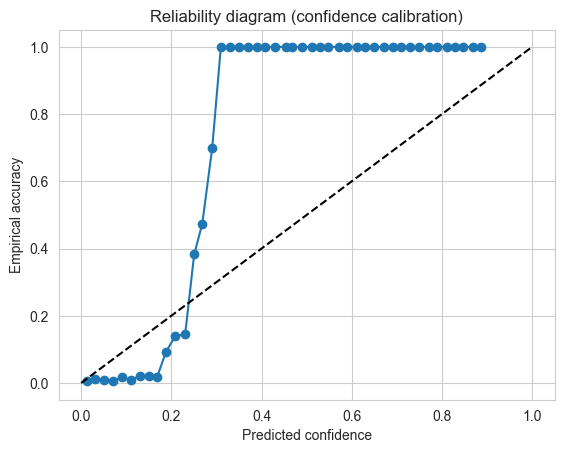

In [85]:
prob_true, prob_pred = calibration_curve(agreement, confidence_final, n_bins=50)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Predicted confidence")
plt.ylabel("Empirical accuracy")
plt.title("Reliability diagram (confidence calibration)")
plt.show()

This plot shows that the model reveals an accuracy of ~1.0 from a confidence of ~0.25 on. Therefore, the model is underconfident for many true predictions. For a confidence < ~0.25, the model is overconfident, meaning that it confidently predicts wrong classes. The optimal behaviour would be the black dashed line.

## Flagging of uncertain classifications for potential human review

In [86]:
def flag_uncertain_predictions(y_pred, confidence, min_confidence_threshold):
    """
    Flags predictions whose confidence score falls below a specified threshold.

    Parameters:
    y_pred (np.array): Predicted class labels.
    confidence (np.array): Calculated confidence scores [0, 1].
    min_confidence_threshold (float): Confidence level below which a prediction is flagged.

    Returns:
    pd.DataFrame: A DataFrame containing predictions, confidence, and the review flag.
    """
    df_results = pd.DataFrame({
        'predicted_label': y_pred,
        'confidence_score': confidence,
        # Flag if confidence is below the threshold
        'needs_review': confidence < min_confidence_threshold
    })
    return df_results

In [87]:
review_df = flag_uncertain_predictions(y_pred_final, confidence_final, 0.08)

In [88]:
review_df['true_label_encoded'] = y_test

In [89]:
# Total percentage flagged
flagged_count = review_df['needs_review'].sum()
total_count = len(review_df)
print(f"Total predictions: {total_count}")
print(f"Predictions flagged for review: {flagged_count} ({flagged_count/total_count:.2%})")

# Check accuracy among reviewed (flagged) items
flagged_indices = review_df[review_df['needs_review']].index.values
if len(flagged_indices) > 0:
    flagged_accuracy = accuracy_score(y_test[flagged_indices], y_pred_final[flagged_indices])
    print(f"Accuracy of Flagged Predictions: {flagged_accuracy:.4f} (These are the difficult samples)")

# Check accuracy among accepted (unflagged) items
accepted_indices = review_df[~review_df['needs_review']].index.values
if len(accepted_indices) > 0:
    accepted_accuracy = accuracy_score(y_test[accepted_indices], y_pred_final[accepted_indices])
    print(f"Accuracy of Accepted Predictions: {accepted_accuracy:.4f} (This should be very high)")

# Number of flagged, but correctly predicted, samples
print(f"Number of flagged, but correctly predicted samples: {len(review_df[
               (review_df["predicted_label"] == review_df["true_label_encoded"]) &
               (review_df["needs_review"] == True)
               ])}")

# --- Display a few samples needing review ---
print("\n--- Samples Needing Human Review ---")

# Define the preferred order of columns for inspection
desired_columns = [
    'predicted_label',
    'true_label_encoded',  # <-- Moved next to predicted_label
    'confidence_score',
    'needs_review'
]

# Filter for flagged samples and display only the desired columns
print(review_df[review_df['needs_review']][desired_columns].head())

Total predictions: 6374
Predictions flagged for review: 1181 (18.53%)
Accuracy of Flagged Predictions: 0.4513 (These are the difficult samples)
Accuracy of Accepted Predictions: 0.8538 (This should be very high)
Number of flagged, but correctly predicted samples: 533

--- Samples Needing Human Review ---
    predicted_label  true_label_encoded  confidence_score  needs_review
17               15                   3          0.079615          True
29               10                   7          0.037756          True
35               10                  20          0.076466          True
36                4                  23          0.043762          True
40               17                  17          0.064926          True


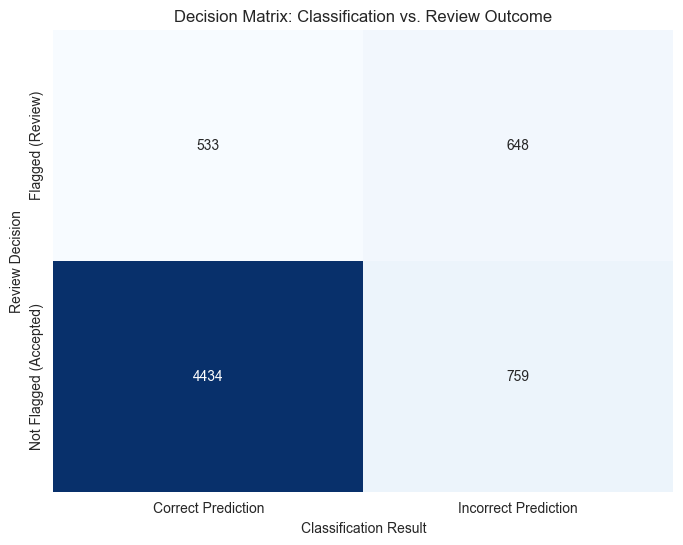

In [90]:
# 1. Determine if the prediction was correct
is_correct = review_df["predicted_label"] == review_df["true_label_encoded"]
review_df['is_correct'] = is_correct

# 2. Define the four quadrants
# (Note: We invert the 'needs_review' logic for clarity in the matrix labels)
is_flagged = review_df['needs_review']
is_accepted = ~is_flagged # Not Flagged

# Quadrant Counts
q_correct_accepted = len(review_df[is_correct & is_accepted])
q_incorrect_accepted = len(review_df[~is_correct & is_accepted])

q_correct_flagged = len(review_df[is_correct & is_flagged])
q_incorrect_flagged = len(review_df[~is_correct & is_flagged])


# 3. Create the Matrix Data Structure
matrix_data = [
    [q_correct_flagged, q_incorrect_flagged],  # Row 1: Flagged
    [q_correct_accepted, q_incorrect_accepted] # Row 2: Not Flagged (Accepted)
]

# 4. Plot the Matrix using Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix_data,
    annot=True,
    fmt='d',  # Display as integer
    cmap='Blues',
    cbar=False,
    xticklabels=['Correct Prediction', 'Incorrect Prediction'],
    yticklabels=['Flagged (Review)', 'Not Flagged (Accepted)']
)

plt.title('Decision Matrix: Classification vs. Review Outcome')
plt.xlabel('Classification Result')
plt.ylabel('Review Decision')
plt.show()

The threshold for the review flag was set to 8%, meaning that a prediction with less than 8% confidence should be reviewed. This results in 1181 flagged samples. Nevertheless, 553 flagged samples were indeed correctly predicted, meaning that the review was unnecessary. On the other hand, 759 falsely predicted samples were not flagged, meaning that they would be wrongly accepted without any human review. For this task, there is a tradeoff between workload and flagging accuracy. If the threshold was set to ~25%, only 47 false predictions would not be reviewed, but therefore 2429 true predictions would be reviewed, which means a huge unnecessary workload.